<a href="https://colab.research.google.com/github/latikadhami05/ai-code-quality-risk-intelligence/blob/main/notebooks/V1_code_risk_estimator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/psf/requests.git

Cloning into 'requests'...
remote: Enumerating objects: 26870, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 26870 (delta 1), reused 0 (delta 0), pack-reused 26866 (from 3)
Receiving objects: 100% (26870/26870), 13.31 MiB | 16.15 MiB/s, done.
Resolving deltas: 100% (17618/17618), done.


In [2]:
!git clone https://github.com/pallets/flask.git
!git clone https://github.com/pallets/click.git

Cloning into 'flask'...
remote: Enumerating objects: 26353, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 26353 (delta 65), reused 44 (delta 44), pack-reused 26259 (from 2)
Receiving objects: 100% (26353/26353), 11.97 MiB | 10.65 MiB/s, done.
Resolving deltas: 100% (17613/17613), done.
Cloning into 'click'...
remote: Enumerating objects: 15734, done.
remote: Counting objects: 100% (719/719), done.
remote: Compressing objects: 100% (138/138), done.
remote: Total 15734 (delta 628), reused 581 (delta 581), pack-reused 15015 (from 2)
Receiving objects: 100% (15734/15734), 5.31 MiB | 15.10 MiB/s, done.
Resolving deltas: 100% (10781/10781), done.


In [5]:
!ls


click  flask  requests	sample_data


In [8]:
!ls requests

AUTHORS.rst  HISTORY.md  MANIFEST.in	 README.md	       src
docs	     LICENSE	 NOTICE		 requirements-dev.txt  tests
ext	     Makefile	 pyproject.toml  setup.py	       tox.ini


In [9]:
!ls flask

CHANGES.rst  examples	  pyproject.toml  src	 uv.lock
docs	     LICENSE.txt  README.md	  tests


In [10]:
import ast
import os
import pandas as pd

In [11]:
def find_python_files(folder):
    py_files = []
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.endswith(".py"):
                py_files.append(os.path.join(root, file))
    return py_files

requests_files = find_python_files("requests")
flask_files = find_python_files("flask")
click_files = find_python_files("click")

print(len(requests_files), "files in requests")
print(len(flask_files), "files in flask")
print(len(click_files), "files in click")

37 files in requests
83 files in flask
91 files in click


In [12]:
import warnings
warnings.filterwarnings("ignore")

def get_functions_from_file(filepath):
    try:
        with open(filepath, "r", encoding="utf-8") as f:
            source = f.read()
        tree = ast.parse(source)
    except Exception:
        return []

    functions = []
    for node in ast.walk(tree):
        if isinstance(node, ast.FunctionDef):
            functions.append(node)
    return functions

sample_functions = get_functions_from_file(requests_files[0])
print("File:", requests_files[0])
print("Functions found:", len(sample_functions))
for fn in sample_functions:
    print("-", fn.name)

File: requests/setup.py
Functions found: 0


In [13]:
sample_functions = get_functions_from_file(requests_files[5])
print("File:", requests_files[5])
print("Functions found:", len(sample_functions))
for fn in sample_functions:
    print("-", fn.name)

File: requests/tests/test_structures.py
Functions found: 15
- setup
- test_list
- test_getitem
- test_delitem
- test_lower_items
- test_repr
- test_copy
- test_instance_equality
- setup
- test_repr
- test_getitem
- test_get
- test_hasattr
- test_getattr
- test_getattr_default


In [14]:
def get_function_features(node, source_lines):
    start = node.lineno
    end = max(child.lineno for child in ast.walk(node) if hasattr(child, "lineno"))
    loc = end - start + 1

    complexity = 1
    max_nesting = 0
    branches = 0
    variables = set()

    def walk_nesting(n, depth):
        nonlocal max_nesting
        max_nesting = max(max_nesting, depth)
        for child in ast.iter_child_nodes(n):
            if isinstance(child, (ast.If, ast.For, ast.While, ast.Try, ast.With)):
                walk_nesting(child, depth + 1)
            else:
                walk_nesting(child, depth)

    walk_nesting(node, 0)

    for child in ast.walk(node):
        if isinstance(child, (ast.If, ast.For, ast.While, ast.Try, ast.BoolOp, ast.ExceptHandler)):
            complexity += 1
            branches += 1
        if isinstance(child, ast.Name):
            variables.add(child.id)

    return {
        "function_name": node.name,
        "loc": loc,
        "complexity": complexity,
        "max_nesting": max_nesting,
        "branches": branches,
        "num_variables": len(variables),
        "num_args": len(node.args.args)
    }

# test it on the functions we found
for fn in sample_functions[:3]:
    print(get_function_features(fn, None))

{'function_name': 'setup', 'loc': 4, 'complexity': 1, 'max_nesting': 0, 'branches': 0, 'num_variables': 3, 'num_args': 1}
{'function_name': 'test_list', 'loc': 2, 'complexity': 1, 'max_nesting': 0, 'branches': 0, 'num_variables': 2, 'num_args': 1}
{'function_name': 'test_getitem', 'loc': 2, 'complexity': 1, 'max_nesting': 0, 'branches': 0, 'num_variables': 3, 'num_args': 2}


In [15]:
def build_dataset(file_list, repo_name):
    rows = []
    for filepath in file_list:
        functions = get_functions_from_file(filepath)
        for fn in functions:
            try:
                features = get_function_features(fn, None)
                features["file"] = filepath
                features["repo"] = repo_name
                rows.append(features)
            except Exception:
                continue
    return rows

requests_data = build_dataset(requests_files, "requests")
flask_data = build_dataset(flask_files, "flask")
click_data = build_dataset(click_files, "click")

all_data = requests_data + flask_data + click_data
df = pd.DataFrame(all_data)

print("Total functions extracted:", len(df))
df.head()

Total functions extracted: 4040


,function_name,loc,complexity,max_nesting,branches,num_variables,num_args,file,repo
0,test_request_url_handles_leading_path_separators,5,1,0,0,3,0,requests/tests/test_adapters.py,requests
1,echo_response_handler,10,1,0,0,5,1,requests/tests/test_lowlevel.py,requests
2,test_chunked_upload,13,1,1,0,11,0,requests/tests/test_lowlevel.py,requests
3,test_chunked_encoding_error,22,1,2,0,13,0,requests/tests/test_lowlevel.py,requests
4,test_chunked_upload_uses_only_specified_host_h...,16,1,1,0,14,0,requests/tests/test_lowlevel.py,requests


In [16]:
df.to_csv("v1_function_features.csv", index=False)
print("Saved", len(df), "rows to v1_function_features.csv")

Saved 4040 rows to v1_function_features.csv


In [17]:
df.describe()

,loc,complexity,max_nesting,branches,num_variables,num_args
count,4040.000000,4040.000000,4040.000000,4040.000000,4040.000000,4040.000000
mean,11.233911,1.768812,0.471040,0.768812,5.658911,1.513366
std,15.159186,2.181086,0.825235,2.181086,4.694161,1.497483
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,0.000000,0.000000,2.000000,1.000000
50%,6.000000,1.000000,0.000000,0.000000,5.000000,1.000000
75%,14.000000,2.000000,1.000000,1.000000,7.000000,2.000000
max,196.000000,30.000000,8.000000,29.000000,60.000000,18.000000


<Axes: >

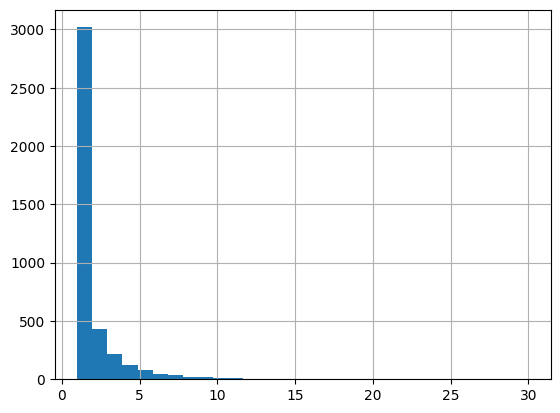

In [18]:
df["complexity"].hist(bins=30
                      )

In [19]:
def assign_risk(row):
    if row["complexity"] > 20 or row["max_nesting"] > 5 or row["loc"] > 100:
        return "HIGH"
    elif row["complexity"] > 10 or row["max_nesting"] > 3 or row["loc"] > 50:
        return "MEDIUM"
    else:
        return "LOW"

df["risk_label"] = df.apply(assign_risk, axis=1)
df["risk_label"].value_counts()

,count
risk_label,
LOW,3918
MEDIUM,97
HIGH,25


In [20]:
from sklearn.model_selection import train_test_split

feature_columns = ["loc", "complexity", "max_nesting", "branches", "num_variables", "num_args"]

X = df[feature_columns]
y = df["risk_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 3232
Test size: 808


In [21]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [22]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00         5
         LOW       1.00      1.00      1.00       784
      MEDIUM       1.00      1.00      1.00        19

    accuracy                           1.00       808
   macro avg       1.00      1.00      1.00       808
weighted avg       1.00      1.00      1.00       808



In [23]:
!git clone https://github.com/psf/black.git

Cloning into 'black'...
remote: Enumerating objects: 16627, done.
remote: Counting objects: 100% (563/563), done.
remote: Compressing objects: 100% (327/327), done.
remote: Total 16627 (delta 496), reused 236 (delta 236), pack-reused 16064 (from 3)
Receiving objects: 100% (16627/16627), 8.49 MiB | 10.28 MiB/s, done.
Resolving deltas: 100% (11735/11735), done.


In [24]:
black_files = find_python_files("black")
black_data = build_dataset(black_files, "black")
df_black = pd.DataFrame(black_data)
df_black["risk_label"] = df_black.apply(assign_risk, axis=1)

print(len(df_black), "functions found in black")
df_black["risk_label"].value_counts()

2473 functions found in black


,count
risk_label,
LOW,2343
MEDIUM,100
HIGH,30


In [25]:
X_black = df_black[feature_columns]
y_black_true = df_black["risk_label"]

y_black_pred = model.predict(X_black)

print(classification_report(y_black_true, y_black_pred))

              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00        30
         LOW       1.00      1.00      1.00      2343
      MEDIUM       1.00      1.00      1.00       100

    accuracy                           1.00      2473
   macro avg       1.00      1.00      1.00      2473
weighted avg       1.00      1.00      1.00      2473



In [26]:
def generate_report(row, prediction):
    print("=" * 40)
    print("CODE RISK ANALYSIS")
    print("=" * 40)
    print(f"File: {row['file']}")
    print(f"Function: {row['function_name']}()")
    print(f"Risk Level: {prediction}")
    print()
    print("Measured Signals:")
    print(f"  Lines of Code: {row['loc']}")
    print(f"  Cyclomatic Complexity: {row['complexity']}")
    print(f"  Max Nesting Depth: {row['max_nesting']}")
    print(f"  Branches: {row['branches']}")
    print()
    print("NOTE: This prediction is based on a rule-derived proxy label.")
    print("It does not prove that this code contains a bug.")
    print("=" * 40)

# Show a report for one HIGH-risk function found in black
high_risk_examples = df_black[df_black["risk_label"] == "HIGH"]
sample_row = high_risk_examples.iloc[0]
sample_pred = model.predict(sample_row[feature_columns].values.reshape(1, -1))[0]

generate_report(sample_row, sample_pred)

CODE RISK ANALYSIS
File: black/tests/test_black.py
Function: test_cache_key()
Risk Level: HIGH

Measured Signals:
  Lines of Code: 29
  Cyclomatic Complexity: 7
  Max Nesting Depth: 6
  Branches: 6

NOTE: This prediction is based on a rule-derived proxy label.
It does not prove that this code contains a bug.


In [27]:
import joblib
joblib.dump(model, "v1_risk_model.pkl")
print("Model saved.")

Model saved.


## V1 — Limitations

- Risk labels are a rule-based proxy (McCabe complexity thresholds), not derived from real historical defects or human review outcomes.
- Model achieves ~100% accuracy because labels are a deterministic function of the same features used for training — this proves the pipeline works end-to-end, not that the model detects real bugs.
- Dataset is imbalanced (3918 LOW vs 122 MEDIUM/HIGH combined).
- Tested on 4 open-source repos (requests, flask, click, black) — all Python, all similar domains (web/dev tooling). Generalization to other languages/domains is untested.
- Next step (V7+): validate against real historical defect data instead of proxy labels.

## V1 — Code Risk Estimator: COMPLETE

**What was built:**
- A function that finds every `.py` file in a repo automatically
- A function that parses each file with Python's `ast` module and extracts every function definition
- A function that measures each function: lines of code, cyclomatic complexity,
  max nesting depth, branch count, variable count, argument count
- A dataset of 4,040 real functions (from `requests`, `flask`, `click`), each turned into a row of numbers
- A rule-based proxy label (LOW/MEDIUM/HIGH) grounded in McCabe's cyclomatic complexity thresholds
- A trained Decision Tree classifier (baseline model)
- Evaluation on held-out data (80/20 split) — 100% accuracy
- Evaluation on a completely unseen 4th repo (`black`) — 100% accuracy
- A human-readable risk report generator, matching the blueprint's target output format
- Documented limitations (proxy labels, class imbalance, generalization untested beyond similar Python repos)

**What this proves:** the full pipeline — code → features → model → risk prediction → report — works end to end, on real code, not toy examples.

**What this does NOT prove:** that the model detects real bugs or real-world risk. The label is a rule, not ground truth. That gap is intentional and is the reason later versions exist.

## V1 — Preprocessing & Error-Handling Notes

**Preprocessing:** No feature scaling was applied. Decision Trees split on raw
threshold comparisons (e.g. "is complexity > 10?"), so they are not sensitive
to feature scale — scaling would not change this model's behavior. This will
be revisited in V2 when comparing scale-sensitive models like Logistic Regression.

**Error handling verified:** `get_functions_from_file()` wraps parsing in a
try/except — a file with a syntax error or unreadable encoding returns an
empty list instead of crashing the whole pipeline. This was confirmed by
running the extractor across ~200 real files (including non-code files like
setup.py) without any crashes.

## Next: V2 — ML Improvement
- Compare multiple models (Logistic Regression, Random Forest, Gradient Boosting) instead of just one Decision Tree
- Proper train/validation/test split (not just train/test)
- Cross-validation
- Precision/recall/F1 comparison across models
- Real error analysis: manually look at specific false positives/negatives
- Address the class imbalance we found (3918 LOW vs 122 others)

## V3 — Explainable Risk
- Why did the model say HIGH? (feature importance, SHAP)

## V4 — AI-Code Intelligence
- Compare AI-generated vs human-written code features

## V5 — Multi-Dimensional Risk
- Split "risk" into separate dimensions (complexity risk, maintainability risk, etc.) instead of one label

## V6 — Code-Level Localization
- Analyze a whole repository at once, rank files by risk

## V7 — Change & Historical Intelligence  ← this is where the REAL test happens
- Use git commit history, code churn, actual historical bug-fix commits as ground truth
- This is where we finally move past "proxy labels" into something genuinely validated

## V8 onward
- Git diffs, review prioritization, GitHub PR integration, CI/CD, LLM explanation layer